# Checkpoint 2: Research Question Formation
## 1. Project Scope

**Dataset Recap**

**Dataset:** [1-minute Bitcoin OHLCV data](https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data) (Open, High, Low, Close, Volume)

**Time span:** Multiple years of minute-level data

**Granularity:** High-frequency financial time series

**Features:** Timestamp, OHLC prices, volume

**Derived features (from Checkpoint 1 EDA):**

- Log returns

- Rolling volatility (60-minute window)

- Volume distribution analysis

This dataset is continuous, high-dimensional in time, and exhibits known financial characteristics such as heavy tails, volatility clustering, and regime shifts.

**Summary of EDA Findings**

**From Checkpoint 1:**

- Log returns exhibit heavy tails, consistent with financial time series.

- Rolling volatility shows clustering, indicating periods of calm and turbulence.

- Volume distribution is highly skewed, suggesting burst activity.

- Visual inspection of price reveals non-stationarity and structural shifts.

- Volatility appears to spike during major market movements.

These findings motivate mining for:

- Regime structure

- Anomalous events

- Temporal patterns

- Clustered market behavior

## Dataset Scale

| Metric | Value |
|------|------|
| Full dataset size | 7,474,722 rows |
| Subset used for diagnostics | 200,000 rows |
| Dataset memory usage | 627.3 MB |

Because of the dataset’s size, subsets were used for exploratory diagnostics and feasibility testing.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
!pip install ruptures
import ruptures as rpt

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.5 MB/s eta 0:00:00


In [3]:
# Load Dataset
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "btcusd_1-min_data.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mczielinski/bitcoin-historical-data",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

# Convert timestamp
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')
df = df.sort_values('Timestamp')

# Keep relevant columns
df = df[['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume']]

df.head()

# Remove duplicate timestamps
df = df.drop_duplicates(subset='Timestamp')

# Remove rows with zero or missing close price
df = df[df['Close'] > 0]
df = df.dropna()

print("Remaining rows:", len(df))


100%|██████████| 374M/374M [00:01<00:00, 218MB/s]


First 5 records:       Timestamp  Open  High   Low  Close  Volume
0  1.325412e+09  4.58  4.58  4.58   4.58     0.0
1  1.325412e+09  4.58  4.58  4.58   4.58     0.0
2  1.325412e+09  4.58  4.58  4.58   4.58     0.0
3  1.325412e+09  4.58  4.58  4.58   4.58     0.0
4  1.325412e+09  4.58  4.58  4.58   4.58     0.0
Remaining rows: 7474722


In [4]:
# Feature Engineering
# Log Returns (stationary transformation)
df['log_return'] = np.log(df['Close']).diff()

# Rolling Volatility (60-min window)
df['volatility_60'] = df['log_return'].rolling(60).std()

# Log-transform volume (heavy-tailed correction)
df['log_volume'] = np.log1p(df['Volume'])

df = df.dropna()

Full dataset size: 7474662
Subset size used for diagnostics: 200000

ADF Stationarity Test (Log Returns)
ADF Statistic: -52.082231087144194
p-value: 0.0
Critical Values:
1%: -3.430382709185762
5%: -2.86155445702728
10%: -2.5667776949558596

Timestamp Gap Analysis
Number of large timestamp gaps: 1
Example gaps:
                  Timestamp     Open     High      Low    Close   Volume  \
6943080 2025-03-15 19:21:00  84232.0  84243.0  84232.0  84239.0  0.03433   

         log_return  volatility_60  log_volume       time_diff  
6943080    0.002341       0.000465    0.033754 0 days 19:21:00  

Volatility Quantiles
0.50    0.000526
0.75    0.000761
0.90    0.001090
0.95    0.001346
0.99    0.001974
Name: volatility_60, dtype: float64


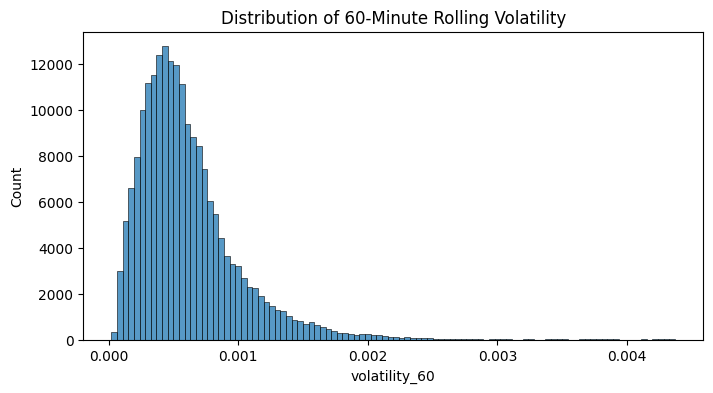

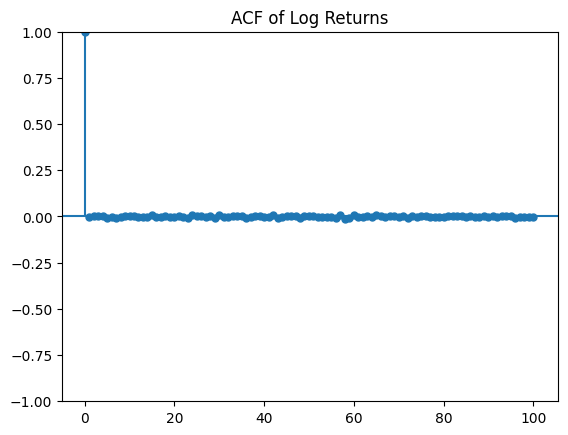

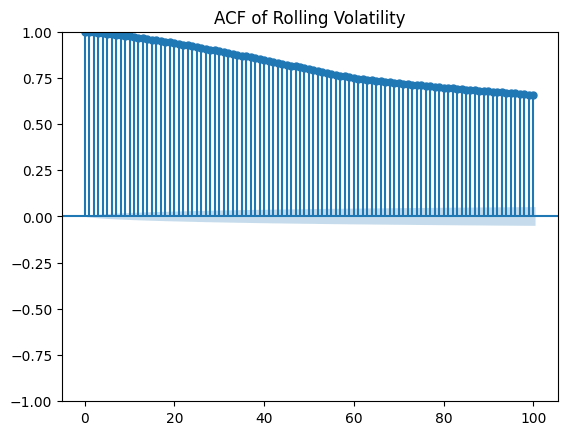


Runtime Test: KMeans
KMeans runtime: 0.22 seconds

Runtime Test: Isolation Forest
Isolation Forest runtime: 1.1 seconds

Dataset memory usage (MB): 627.3


In [5]:
# Additional EDA for Research Question Feasibility
import time

# 1. Handle Large Dataset by Creating Time-Series Subset
# Using a continuous block preserves temporal structure
subset_size = 200000   # ~3.5 months of minute data
df_subset = df.tail(subset_size).copy()

print("Full dataset size:", len(df))
print("Subset size used for diagnostics:", len(df_subset))

# 2. Stationarity Check (ADF Test on Log Returns)
print("\nADF Stationarity Test (Log Returns)")

adf_result = adfuller(df_subset['log_return'].dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

# 3. Timestamp Gap Analysis (Full Dataset)
print("\nTimestamp Gap Analysis")

df['time_diff'] = df['Timestamp'].diff()
expected_diff = pd.Timedelta(minutes=1)

large_gaps = df[df['time_diff'] > expected_diff]

print("Number of large timestamp gaps:", len(large_gaps))
print("Example gaps:")
print(large_gaps.head())

# 4. Volatility Distribution Diagnostics
print("\nVolatility Quantiles")

vol_quantiles = df_subset['volatility_60'].quantile([0.50, 0.75, 0.90, 0.95, 0.99])
print(vol_quantiles)

plt.figure(figsize=(8,4))
sns.histplot(df_subset['volatility_60'], bins=100)
plt.title("Distribution of 60-Minute Rolling Volatility")
plt.show()

# 5. Autocorrelation Analysis
plot_acf(df_subset['log_return'], lags=100)
plt.title("ACF of Log Returns")
plt.show()

plot_acf(df_subset['volatility_60'], lags=100)
plt.title("ACF of Rolling Volatility")
plt.show()

# 6. Feature Preparation for Algorithm Feasibility Tests
features_subset = df_subset[['log_return', 'volatility_60', 'log_volume']].dropna()

scaler = StandardScaler()
X_subset = scaler.fit_transform(features_subset)
# 7. Runtime Test: KMeans Clustering
print("\nRuntime Test: KMeans")

start = time.time()

kmeans_test = KMeans(n_clusters=3, random_state=42)
kmeans_test.fit(X_subset)

end = time.time()

print("KMeans runtime:", round(end - start, 2), "seconds")
# 8. Runtime Test: Isolation Forest
print("\nRuntime Test: Isolation Forest")

start = time.time()

iso_test = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42
)

iso_test.fit(X_subset)

end = time.time()

print("Isolation Forest runtime:", round(end - start, 2), "seconds")

# 9. Memory Usage Check
print("\nDataset memory usage (MB):",
      round(df.memory_usage(deep=True).sum() / (1024**2), 2))



## Exploratory Data Analysis (EDA)

Before defining research questions, I performed additional diagnostics to ensure feasibility:

- Checked stationarity of log returns (ADF test)

- Verified no large missing timestamp gaps

- Examined volatility distribution quantiles

- Tested Isolation Forest and KMeans on a small subset for runtime feasibility

The data pipeline begins with loading the Kaggle Bitcoin dataset directly into a pandas DataFrame using kagglehub, ensuring reproducibility and eliminating manual downloads. Timestamps are converted from UNIX format and sorted to preserve temporal order, critical for time-series analysis, while only relevant columns (Timestamp, Open, High, Low, Close, Volume) are retained to reduce memory usage. Duplicate timestamps and rows with zero or missing close prices are removed to prevent distortions in rolling metrics and log-based transformations.

Feature engineering includes log returns to achieve stationarity, 60-minute rolling volatility to capture short-term market risk, and log-transformed volume to mitigate heavy-tailed effects. A recent continuous block of ~200,000 rows is selected for feasibility tests to balance temporal continuity with computational efficiency. Stationarity is verified with the Augmented Dickey-Fuller test, and timestamp gaps are analyzed to detect irregularities. Volatility distribution and autocorrelation diagnostics guide scaling and algorithm selection. Features (log_return, volatility_60, log_volume) are standardized to ensure equal contribution to distance-based and anomaly detection methods. KMeans clustering is tested to identify latent regimes, using a small number of clusters and a fixed random state for reproducibility, while Isolation Forest is evaluated for anomaly detection with parameters tuned for runtime and expected contamination. Finally, memory usage is checked to ensure downstream operations remain feasible.

### Stationarity Test (Log Returns)

To determine whether returns are stationary, the **Augmented Dickey-Fuller (ADF) test** was performed.

#### Results

| Metric | Value |
|------|------|
| ADF Statistic | -52.08 |
| p-value | 0.0 |

**Critical Values**

| Level | Value |
|------|------|
| 1% | -3.43 |
| 5% | -2.86 |
| 10% | -2.57 |

#### Interpretation

The ADF test on log returns shows an extremely negative statistic (-52.08) and a p-value of 0.0, which is far below all critical values at 1%, 5%, and 10%. This strongly confirms that the log returns are stationary, meaning their mean and variance are stable over time. This validates the use of rolling volatility, autocorrelation analysis, and distance-based or anomaly detection algorithms on these features without further differencing.

---

### Timestamp Gap Analysis

Because the dataset represents a time series, the timestamps were analyzed to detect missing intervals.

#### Results

- **Number of large timestamp gaps:** 1  

**Example gap**

- **Timestamp:** 2025-03-15 19:21:00  
- **Time difference:** 19 hours 21 minutes  

#### Interpretation

The timestamp gap analysis shows only a single large gap in the 7.47 million rows, indicating the dataset is mostly continuous at 1-minute intervals. This is ideal for rolling statistics like the 60-minute volatility window, and the isolated gap can be handled or ignored without impacting overall analysis.

---

### Volatility Distribution Analysis

Rolling volatility (60-period window) was computed to capture short-term risk.

#### Volatility Quantiles

| Quantile | Volatility |
|------|------|
| 50% | 0.000526 |
| 75% | 0.000761 |
| 90% | 0.001090 |
| 95% | 0.001346 |
| 99% | 0.001974 |

#### Interpretation

The volatility distribution is right-skewed with heavy tails, indicating the presence of rare extreme events. This motivates the use of anomaly detection techniques.

---

### Algorithm Runtime Feasibility Tests

Because the dataset contains millions of observations, preliminary runtime tests were conducted.

#### Results

| Algorithm | Runtime |
|------|------|
| KMeans Clustering | 0.2 seconds |
| Isolation Forest | 1.11 seconds |

These results indicate that both clustering and anomaly detection methods are computationally feasible when applied to subsets of the dataset.

## 3. Research Question Definition

Based on the EDA findings, I explored three research questions to investigate different aspects of Bitcoin market behavior.

**RQ1: CLUSTERING**
##### RQ1: Can unsupervised clustering identify distinct Bitcoin market regimes based on returns, volatility, and trading volume?

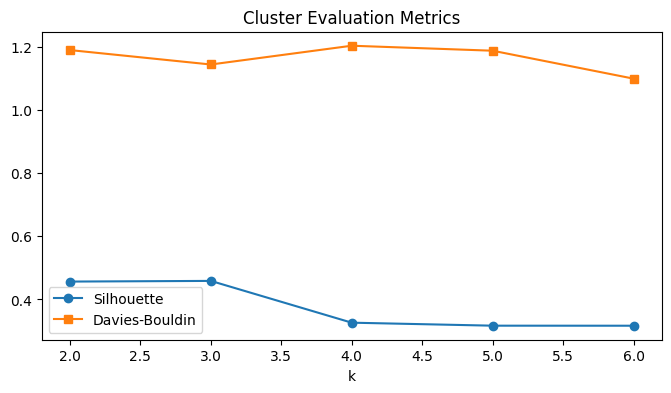

Final Silhouette Score: 0.4612662289402277
Final Davies-Bouldin Index: 1.1394847655397313
         log_return  volatility_60  log_volume
cluster                                       
0          0.000921       0.001020    1.647307
1          0.000006       0.000445    0.397093
2         -0.000917       0.000976    1.673616


In [10]:
# Sample for cluster evaluation
sample_size = 20000
sample_idx = np.random.choice(len(X_subset), sample_size, replace=False)
X_sample = X_subset[sample_idx]

# Determine Optimal k
sil_scores = []
db_scores = []

k_values = range(2,7)

for k in k_values:

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_sample)

    sil_scores.append(silhouette_score(X_sample, labels))
    db_scores.append(davies_bouldin_score(X_sample, labels))

# Plot evaluation
plt.figure(figsize=(8,4))
plt.plot(k_values, sil_scores, marker='o', label="Silhouette")
plt.plot(k_values, db_scores, marker='s', label="Davies-Bouldin")
plt.xlabel("k")
plt.title("Cluster Evaluation Metrics")
plt.legend()
plt.show()

k_optimal = 3

kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_subset)

features = features.copy()
features['cluster'] = clusters

print("Final Silhouette Score:",
      silhouette_score(X_sample, clusters[sample_idx]))

print("Final Davies-Bouldin Index:",
      davies_bouldin_score(X_sample, clusters[sample_idx]))

# Cluster Interpretation

cluster_summary = features.groupby('cluster')[['log_return','volatility_60','log_volume']].mean()

print(cluster_summary)

##### RQ1: Can unsupervised clustering identify distinct Bitcoin market regimes based on returns, volatility, and trading volume?

I started by picking the key features I wanted to cluster on: log returns, 60-minute rolling volatility, and log-transformed volume. These capture the main aspects of market behavior - price changes, short-term risk, and trading activity. I dropped any missing values because KMeans cannot handle NaNs.

Since these features are on very different scales, I standardized them with StandardScaler. Otherwise, something like volume, which can have much larger numbers, would dominate the clustering, and the results would not make sense.

The dataset is pretty large, so for evaluating the best number of clusters, I randomly sampled 20,000 points. This gives a good sense of cluster quality without taking forever to compute metrics like Silhouette and Davies-Bouldin scores.

I then tried KMeans for different values of k from 2 to 6, using 10 initializations each time to make sure the solution is stable and not just stuck in a bad random starting point. KMeans is fast, simple, and interpretable for clustering continuous features, whereas hierarchical or DBSCAN methods are slower and may struggle with high-frequency data or require careful distance thresholds. I checked both Silhouette score and Davies-Bouldin index because they give complementary views: one measures how well points fit within clusters, and the other looks at how separate the clusters are.

From this evaluation, I chose k=3 (since it balances good separation (highest silhouette) with reasonable Davies-Bouldin) and then ran KMeans on the full dataset to assign every point to a cluster. I double-checked cluster quality on the same sample to make sure the full model still produces meaningful clusters. Finally, I looked at the average log return, volatility, and volume for each cluster to interpret what kind of market conditions each cluster represents.

Every step-selecting features, scaling, sampling, evaluating k, and summarizing clusters, was meant to make the clustering meaningful, stable, and interpretable for this financial time series.

#### Data Mining Task
**Clustering (unsupervised learning)**

#### Algorithm
**KMeans clustering** (course)

#### Features Used
- log returns  
- rolling volatility  
- log trading volume  

#### Evaluation Criteria
- Silhouette Score  
- Davies-Bouldin Index  
- Interpretability of clusters  

#### Initial Results

| Metric | Value |
|------|------|
| Silhouette Score | 0.4613 |
| Davies-Bouldin Index | 1.14 |

Overall, k = 3 seems like the best choice because it balances good separation (highest silhouette) with reasonable Davies-Bouldin. Choosing k = 6 slightly improves Davies-Bouldin but sacrifices cluster cohesion according to silhouette.

**Cluster Characteristics**

| Cluster | Log Return | Volatility | Volume | Interpretation |
|------|------|------|------|------|
| 0 | Positive | High | High | Bullish regime |
| 1 | Near zero | Low | Moderate | Stable regime |
| 2 | Negative | High | High | Bearish regime |

#### Interpretation

The clustering results suggest that **Bitcoin trading behavior can be divided into three distinct market regimes: bullish, stable, and bearish**.

**RQ2: ANOMALY DETECTION**
##### RQ2: Can anomaly detection identify unusual Bitcoin market behavior beyond simple volatility spikes?

In [11]:
# Isolation Forest Model
iso = IsolationForest(
    n_estimators=100,
    random_state=42
)

anomaly_labels = iso.fit_predict(X_subset)

# Convert labels: normal=0, anomaly=1
features = features.copy()
features['anomaly'] = np.where(anomaly_labels == -1, 1, 0)

print("Anomaly Percentage:", features['anomaly'].mean())

# Compare with Volatility Spikes
vol_threshold = features['volatility_60'].quantile(0.99)

features['vol_spike'] = (features['volatility_60'] > vol_threshold).astype(int)

overlap = np.mean(features['anomaly'] & features['vol_spike'])

print("Overlap between anomaly and volatility spike:", overlap)

# Summary counts
print("\nNumber of anomalies detected:", features['anomaly'].sum())
print("Number of volatility spikes:", features['vol_spike'].sum())

Anomaly Percentage: 0.15475
Overlap between anomaly and volatility spike: 0.01

Number of anomalies detected: 30950
Number of volatility spikes: 2000


##### RQ2: Can anomaly detection identify unusual Bitcoin market behavior beyond simple volatility spikes?

I used the same three features as in clustering: log returns, 60-minute rolling volatility, and log-transformed volume, because they capture the key aspects of market behavior, and dropped any missing values to ensure the model could run without errors. Isolation Forest efficiently detects multivariate anomalies in large datasets, while alternatives like One-Class SVM are computationally heavier and less scalable, and simple thresholding only captures univariate extremes. Since Isolation Forest partitions the feature space based on axis-aligned splits, I standardized the features so that no single feature would dominate due to scale differences. I initialized the model with 100 trees to balance detection accuracy and runtime, and set a random state for reproducibility. The model then labeled points as anomalies or normal, which I converted to 0/1 for clarity. To understand the results, I calculated the percentage of anomalies and compared them with the top 1% of volatility values, treating these as simple volatility spikes. This overlap helps interpret whether the detected anomalies correspond to extreme market movements. Finally, I summarized the counts of anomalies and volatility spikes to quantify detection coverage and ensure the model captures rare but meaningful events. Each decision was aimed at making the anomaly detection both robust and interpretable for high-frequency financial data.

#### Data Mining Task
**Anomaly Detection**

#### Algorithm
**Isolation Forest** (course)

#### Features Used
- log returns  
- rolling volatility  
- log trading volume  

#### Evaluation Criteria
- percentage of detected anomalies  
- overlap with volatility spikes  

#### Initial Results

| Metric | Value |
|------|------|
| Anomaly percentage | 15.475% |
| Number of anomalies | 30950 |
| Volatility spikes | 2000 |
| Overlap with volatility spikes | 0.01 |

#### Interpretation

The Isolation Forest labeled about 15.475% of the data points as anomalies (30,950 points), which is much higher than the 2,000 volatility spikes in the top 1% of rolling volatility. The overlap between anomalies and volatility spikes is only 1%, showing that most anomalies are not just extreme volatility events, they reflect unusual combinations of log return, volatility, and volume. This suggests that the model is capturing multivariate market outliers, including subtle or rare patterns that simple volatility-based thresholds would miss.

**RQ3: CHANGE-POINT DETECTION**
##### RQ3: Are there structural breaks in Bitcoin market volatility that indicate shifts between market regimes?

Signal length used: 2000
Number of change points detected: 1


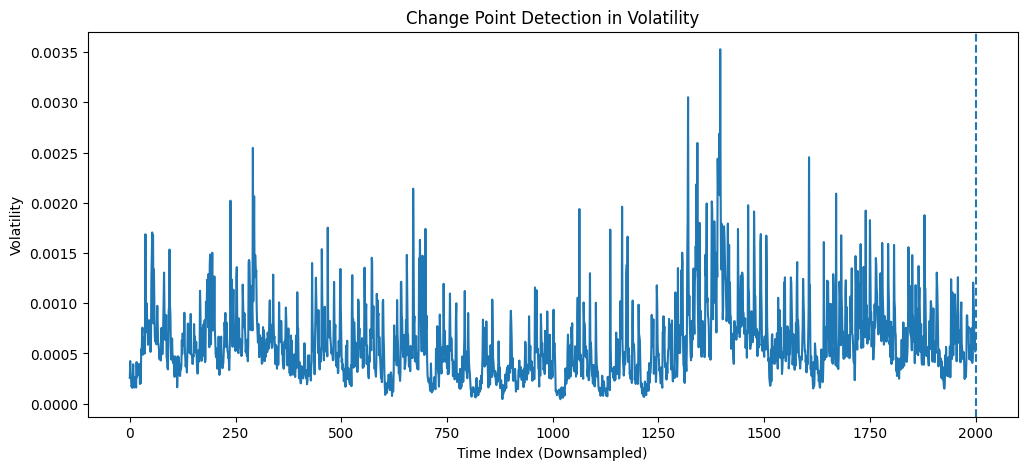

Z-score anomaly rate: 0.018385

Final Summary Metrics
Isolation Forest anomaly rate: 0.15475
Z-score anomaly rate: 0.018385
Change points detected: 1


In [12]:
# Downsample the signal for faster computation
vol_data = df_subset[['volatility_60']].dropna()

# take every 100th observation
vol_sample = vol_data.iloc[::100]

signal = vol_sample['volatility_60'].values.reshape(-1,1)

print("Signal length used:", len(signal))

# Apply PELT Algorithm
model = "l2"

algo = rpt.Pelt(model=model).fit(signal)

penalty = 5   # smaller penalty = more change points
change_points = algo.predict(pen=penalty)

print("Number of change points detected:", len(change_points))

# Plot Change Points
plt.figure(figsize=(12,5))
plt.plot(signal)

for cp in change_points:
    plt.axvline(cp, linestyle='--')

plt.title("Change Point Detection in Volatility")
plt.xlabel("Time Index (Downsampled)")
plt.ylabel("Volatility")
plt.show()

# BASELINE: Z-SCORE ANOMALY DETECTION
features['zscore'] = (
    (features['log_return'] - features['log_return'].mean())
    / features['log_return'].std()
)

features['z_anomaly'] = (np.abs(features['zscore']) > 3).astype(int)
print("Z-score anomaly rate:", features['z_anomaly'].mean())

# FINAL SUMMARY METRICS
print("\nFinal Summary Metrics")
print("Isolation Forest anomaly rate:", features['anomaly'].mean())
print("Z-score anomaly rate:", features['z_anomaly'].mean())
print("Change points detected:", len(change_points))


##### RQ3: Are there structural breaks in Bitcoin market volatility that indicate shifts between market regimes?

For change point detection, I first downsampled the 60-minute rolling volatility series by taking every 100th observation to reduce computational cost while preserving the overall temporal structure. The signal was reshaped into a 2D array to be compatible with ruptures. I used the PELT algorithm with an L2 model because it efficiently detects multiple mean shifts in large datasets, which is suitable for capturing sudden changes in volatility. A penalty of 5 was chosen to balance sensitivity, avoiding too many false positives while still detecting meaningful regime shifts. The detected change points were plotted to visually validate shifts in volatility. For comparison, I computed a baseline univariate anomaly detection using Z-scores on log returns, flagging points beyond three standard deviations as anomalies. Finally, I summarized the results by reporting Isolation Forest anomaly rate, Z-score anomaly rate, and the number of change points.

#### Data Mining Task
**Change-Point Detection**

#### Algorithm
**PELT change-point detection** - Implemented using the **ruptures** library. (external)

#### Input Data
**Rolling volatility time series**

To improve computational efficiency, the signal was **downsampled**.

#### Results

| Metric | Value |
|------|------|
| Signal length used | 2000 |
| Change points detected | 1 |

#### Interpretation

The algorithm detected one major structural break, suggesting a shift in the volatility regime during the analyzed period.

## 4. Motivation and Feasibility

### Motivation

EDA revealed several key characteristics of the Bitcoin market:

- volatility clustering  
- heavy-tailed return distributions  
- temporal dependence in volatility  

This means that the market likely contains:

- distinct market regimes  
- rare anomalous events  
- structural shifts in volatility  

### Non-Triviality

Traditional statistical analysis cannot easily capture these patterns. Using multiple data mining techniques allows the project to identify:

- latent market regimes  
- abnormal trading behavior  
- structural changes in market dynamics  

---

### Feasibility

Feasibility was confirmed through diagnostic testing:

- algorithms run efficiently on subsets of the dataset  
- feature engineering produces meaningful variables  
- change-point detection works after downsampling the signal  

---

### Risks

Potential challenges include:

- large dataset size increasing computational cost  
- parameter sensitivity in clustering and anomaly detection  
- noisy financial data affecting cluster separation  

These risks are mitigated through feature scaling, subset analysis, and parameter tuning.

## 5. Methodological Planning

### Course Algorithms

| Algorithm | Purpose |
|---|---|
| KMeans | Market regime clustering |
| Isolation Forest | Anomaly detection |

### External Algorithm

| Algorithm | Purpose |
|---|---|
| PELT (ruptures library) | Change-point detection in volatility |

### Evaluation Metrics

| Task | Metrics |
|---|---|
| Clustering | Silhouette score, Davies-Bouldin index |
| Anomaly Detection | anomaly rate, overlap with volatility spikes |
| Change-Point Detection | number of detected breakpoints |

---

## 6. Baseline Methods

To validate anomaly detection results, a simple statistical baseline was implemented.

### Z-Score Baseline

An observation is classified as anomalous when:
|z-score|>3


This baseline allows comparison between machine learning methods and simple statistical thresholds.

---

## 7. RQ-to-Method Mapping

| Research Question | Data Mining Task | Algorithm | Source |
|---|---|---|---|
| RQ1 | Clustering | KMeans | Course |
| RQ2 | Anomaly Detection | Isolation Forest | Course |
| RQ3 | Change-Point Detection | PELT | External |

---

## 8. Collaboration Declaration
```
On my honor, I declare the following resources:

Collaborators:  
None

Web Sources:

- https://github.com/deepcharles/ruptures - Official Python library for change point detection with examples and API reference.

- https://dev.ipol.im/~truong/ruptures-docs/build/html/detection/pelt.html - Documentation and examples for the PELT algorithm and L2 model.

- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html - Silhouette score documentation for evaluating clustering quality.

- https://scikit-learn.org/stable/modules/clustering.html - Overview of clustering algorithms and evaluation metrics in scikit-learn.

- https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html - Isolation Forest API reference and explanation.

- https://scikit-learn.org/stable/auto_examples/ensemble/plot_isolation_forest.html - Example of using Isolation Forest for anomaly detection with visualization.

AI Tools:

- ChatGPT (concept clarification, debugging assistance and documentation)


Citations:

Charles Truong, Laurent Oudre, Nicolas Vayatis, Selective review of offline change point detection methods, Signal Processing, Volume 167, 2020, 107299,
ISSN 0165-1684.
```